# 3 Quarantine

Here we show how quarantine is implemented in the model and how it affects the model.

In [1]:
import numpy as np

from EpiCommute import SIRModel

# Model setup

We again use a simple system, with a random mobility `mobility_baseline`.

Now we assume that mobility has been reduced due to lockdown measures. The new mobility is given by the matrix `mobility_current`, which is simply the baseline mobility flows reduced by random factors.

In [2]:
# Number and size of subpopulations
M = 20
subpopulation_sizes = np.random.randint(20,100,M)

# Initialize a random mobility matrix
mobility_baseline = np.random.rand(M, M)

# We assume mobility has decreased due to lockdown
mobility_current = mobility_baseline * (( np.random.rand(M,M) *0.5 ) + 0.5 )

In [3]:
mobility_baseline

array([[0.2330532 , 0.57389166, 0.29024527, 0.89422989, 0.50686091,
        0.28270586, 0.32846051, 0.28708887, 0.75458035, 0.8266471 ,
        0.34034461, 0.10118029, 0.74753997, 0.76298378, 0.35115462,
        0.44746339, 0.17724167, 0.54645024, 0.11685322, 0.24986287],
       [0.15619752, 0.00560705, 0.52118303, 0.93621983, 0.61321284,
        0.0994668 , 0.39422489, 0.88590457, 0.44934397, 0.78673673,
        0.4051804 , 0.22646165, 0.69208901, 0.14247538, 0.078316  ,
        0.01290892, 0.13808836, 0.35087953, 0.01606855, 0.26224314],
       [0.64809468, 0.79025548, 0.14206072, 0.82356954, 0.94944675,
        0.5590401 , 0.18432773, 0.33288194, 0.81499126, 0.14864825,
        0.90889738, 0.43520464, 0.26589705, 0.48012659, 0.43995644,
        0.80872594, 0.17873854, 0.89495727, 0.89728039, 0.13824994],
       [0.8497886 , 0.77354019, 0.50574117, 0.73826929, 0.54475537,
        0.06603475, 0.17183347, 0.78178783, 0.5441896 , 0.81725611,
        0.58800181, 0.93402334, 0.88401221, 0

## Quarantine scenarios

Quarantine is implemented in two different ways in the model:

 - The `isolation` scenario assumes that the reduced mobility means that individual stay at home, and are effectively removed from the dynamices.
 - The `distancing` scenario instead assumes that the reduced mobility corresponds to a reduction in contacts between individuals.
 
More detailed descriptions of both scenarios are given in the manuscript.

## Initialize and run scenarios

We now initialize and run three different variations of the model: no quarantine, isolation, and distancing.


In [4]:
model_no_quarantine = SIRModel(
            mobility_baseline,
            subpopulation_sizes,
            quarantine_mode = None,
            outbreak_source=0,
            VERBOSE=True
        )

model_isolation = SIRModel(
            mobility_current,
            subpopulation_sizes,
            mobility_baseline=mobility_baseline,   
            quarantine_mode = 'isolation',
            outbreak_source=0,
            VERBOSE=True
        )

model_distancing = SIRModel(
            mobility_current,
            subpopulation_sizes,
            mobility_baseline=mobility_baseline,   
            quarantine_mode = 'distancing',
            outbreak_source=0,
            VERBOSE=True
        )

Run simulations

In [5]:
results_no_quarantine = model_no_quarantine.run_simulation()

Starting Simulation ...
Simulation completed
Time: 0min 2.55s


In [6]:
results_isolation = model_isolation.run_simulation()

Starting Simulation ...
Simulation completed
Time: 0min 2.52s


In [7]:
results_distancing = model_distancing.run_simulation()

Starting Simulation ...
Simulation completed
Time: 0min 3.07s


## Comparison of results

We can see that both quarantine-scenarios "flatten the curve". 

The ``isolation`` scenario shows a flatter curve on average (but as we only run one simulation this doesn't have to be the case.

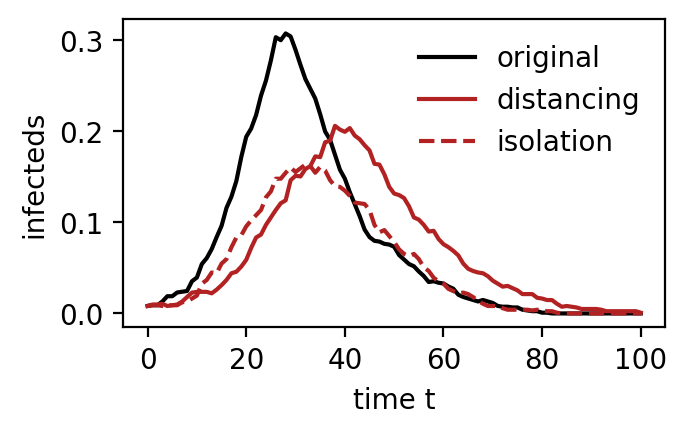

In [8]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc('figure', dpi=200)

fig = plt.figure(figsize=(3.5,2))
plt.plot(results_no_quarantine['t'], results_no_quarantine['I_total'], label='original', color='k')
plt.plot(results_distancing['t'], results_distancing['I_total'], label='distancing', color='firebrick')
plt.plot(results_isolation['t'], results_isolation['I_total'], label='isolation', color='firebrick', linestyle='--')

plt.legend(frameon=False)
plt.xlabel("time t")
plt.ylabel("infecteds")
plt.show()